In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("insurance_dataset.csv")


In [6]:
df.head(3)

,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges
0,46,male,21.45,5,yes,southeast,Diabetes,NaN,Never,Blue collar,Premium,20460.307669
1,25,female,25.38,2,yes,northwest,Diabetes,High blood pressure,Occasionally,White collar,Premium,20390.899218
2,38,male,44.88,2,yes,southwest,NaN,High blood pressure,Occasionally,Blue collar,Premium,20204.476302


In [7]:
df.shape

(1000000, 12)

In [8]:
df.isnull().sum()

age                            0
gender                         0
bmi                            0
children                       0
smoker                         0
region                         0
medical_history           250762
family_medical_history    250404
exercise_frequency             0
occupation                     0
coverage_level                 0
charges                        0
dtype: int64

In [9]:
df = df.fillna("NO")

In [10]:
df.isnull().sum()

age                       0
gender                    0
bmi                       0
children                  0
smoker                    0
region                    0
medical_history           0
family_medical_history    0
exercise_frequency        0
occupation                0
coverage_level            0
charges                   0
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     1000000 non-null  int64  
 1   gender                  1000000 non-null  str    
 2   bmi                     1000000 non-null  float64
 3   children                1000000 non-null  int64  
 4   smoker                  1000000 non-null  str    
 5   region                  1000000 non-null  str    
 6   medical_history         1000000 non-null  str    
 7   family_medical_history  1000000 non-null  str    
 8   exercise_frequency      1000000 non-null  str    
 9   occupation              1000000 non-null  str    
 10  coverage_level          1000000 non-null  str    
 11  charges                 1000000 non-null  float64
dtypes: float64(2), int64(2), str(8)
memory usage: 151.1 MB


In [12]:
age_group = df["age"].value_counts().sort_index(ascending = True)

In [13]:
age_group

age
18    20990
19    20904
20    20851
21    20627
22    20905
23    20825
24    20819
25    20621
26    20911
27    20796
28    20882
29    20884
30    21049
31    20717
32    20897
33    20732
34    20880
35    20912
36    20741
37    20819
38    20824
39    20861
40    20976
41    20734
42    20945
43    21097
44    20707
45    20706
46    20885
47    20766
48    20766
49    20799
50    20851
51    20797
52    20913
53    20899
54    20573
55    20859
56    20648
57    20797
58    20781
59    20907
60    20861
61    20773
62    20895
63    20893
64    20970
65    20755
Name: count, dtype: int64

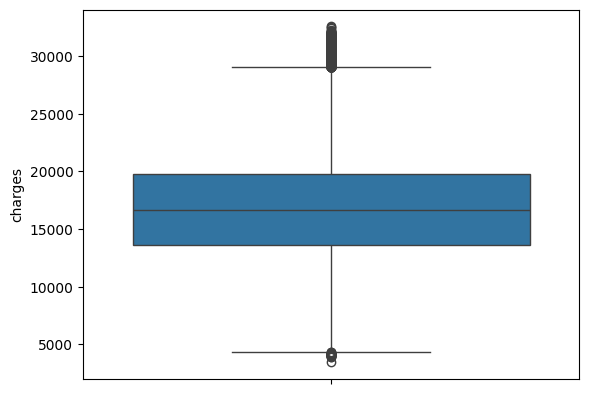

In [14]:
sns.boxplot(data = df, y = "charges")
plt.show()

In [15]:
g = df.columns

In [16]:
g

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region',
       'medical_history', 'family_medical_history', 'exercise_frequency',
       'occupation', 'coverage_level', 'charges'],
      dtype='str')

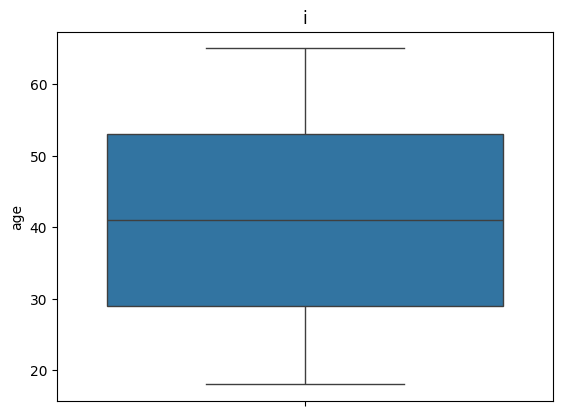

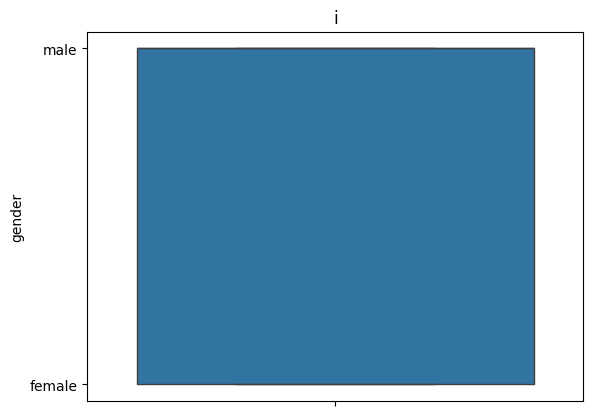

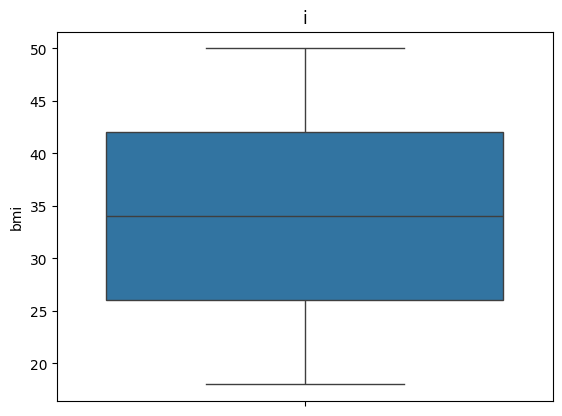

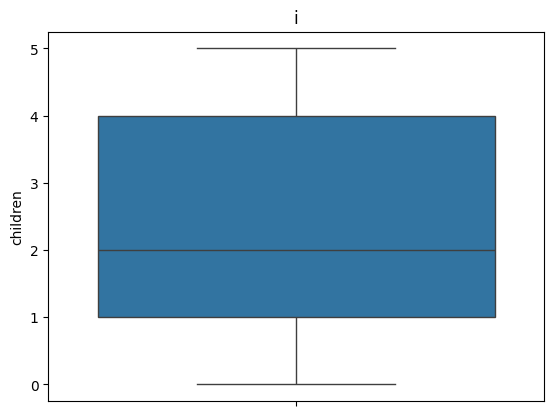

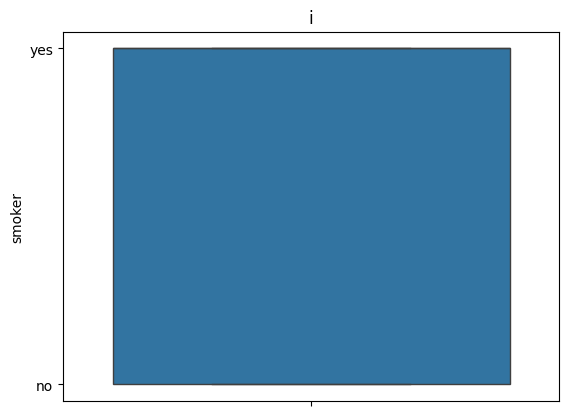

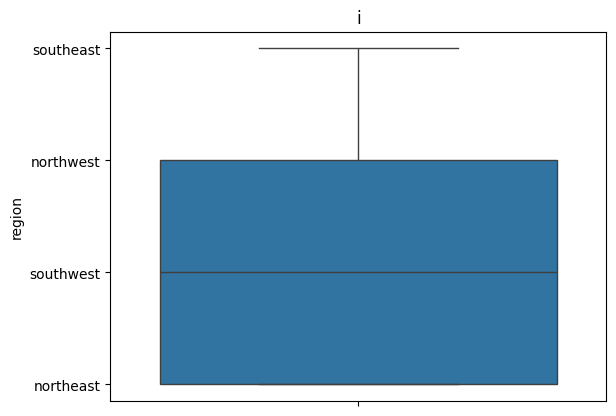

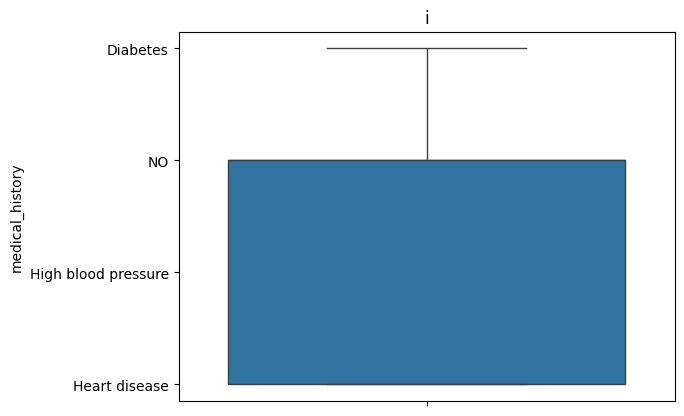

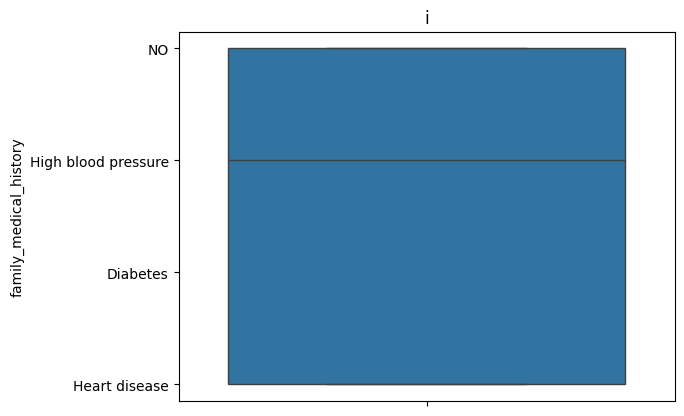

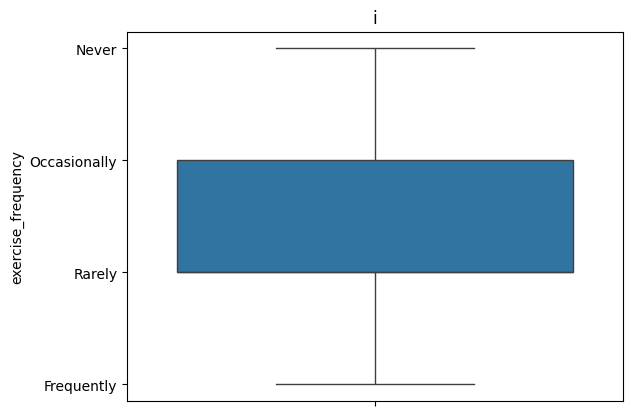

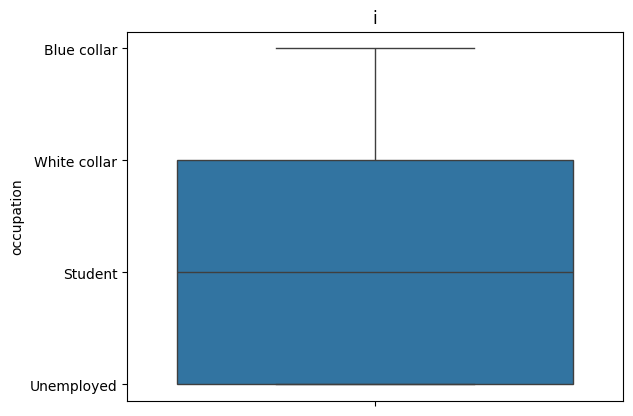

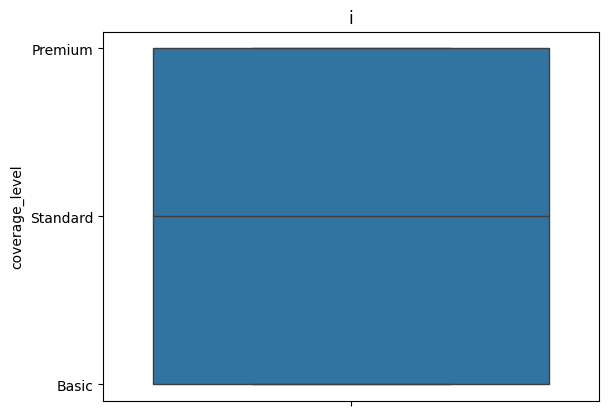

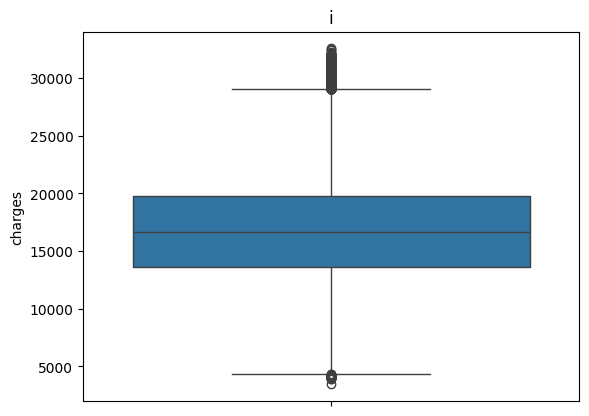

In [29]:
for i in g:
    sns.boxplot(data = df, y = i)
    plt.title("i")
    plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

In [21]:
X = df.drop("charges", axis = 1)
y = df["charges"]

In [22]:
df.head(1)

,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges
0,46,male,21.45,5,yes,southeast,Diabetes,NO,Never,Blue collar,Premium,20460.307669


In [23]:
num_cols = [
    "age",
    "bmi",
    "children",
    
]

In [24]:
cat_cols = [
    "gender",
    "smoker",
    "region",
    "medical_history",
    "family_medical_history",
    "exercise_frequency",
    "occupation",
    "coverage_level"
]

In [25]:
num_transformer = Pipeline([
  ("scaler",StandardScaler())
])

In [26]:
cat_transformer = Pipeline([
    ("encoder",OneHotEncoder()) 
])

In [27]:
preprocessor  = ColumnTransformer([
    ("num",num_transformer,num_cols),
    ("cat",cat_transformer,cat_cols)
])

In [28]:
model_pipeline = Pipeline([
    ("preprocessing",preprocessor),
    ("model",XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size =0.42,random_state = 42)

In [30]:
model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [31]:
pred = model_pipeline.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.9954726038334273
MAE: 255.0601056530984


In [33]:
from sklearn.metrics import r2_score, mean_absolute_error

train_pred = model_pipeline.predict(X_train)

print("Train R2:", r2_score(y_train, train_pred))
print("Train MAE:", mean_absolute_error(y_train, train_pred))

Train R2: 0.9955948597985809
Train MAE: 251.86126350878456


In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_pipeline, X, y, cv=5, scoring="r2")

print(scores)
print(scores.mean())

[0.99547877 0.99552769 0.99552062 0.99551273 0.99549047]
0.9955060565065021


In [35]:
X_encoded = model_pipeline.named_steps['preprocessing'].transform(X)

import pandas as pd

X_encoded_df = pd.DataFrame(X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded)

X_encoded_df["charges"] = y.values

X_encoded_df.corr()["charges"].sort_values(ascending=False)

charges    1.000000
6          0.566213
28         0.426814
16         0.393117
12         0.392891
19         0.146706
26         0.130456
4          0.113526
1          0.104429
2          0.076801
7          0.065537
23         0.065128
0          0.063390
21         0.017532
11         0.001431
9          0.000449
15         0.000155
8         -0.026989
10        -0.039025
22        -0.050772
29        -0.051592
24        -0.065194
20        -0.113486
3         -0.113526
25        -0.130134
17        -0.131201
13        -0.132271
14        -0.261887
18        -0.261978
27        -0.375051
5         -0.566213
Name: charges, dtype: float64

In [36]:
model_pipeline.named_steps["model"].feature_importances_

array([0.00188585, 0.00351617, 0.00369266, 0.01146939, 0.        ,
       0.281086  , 0.        , 0.00631007, 0.0017748 , 0.00202916,
       0.00118769, 0.0317658 , 0.13284297, 0.01591997, 0.02260559,
       0.02171043, 0.11810961, 0.01449625, 0.02277097, 0.01727692,
       0.00830047, 0.00495961, 0.00706912, 0.01494028, 0.01533051,
       0.01171815, 0.01155549, 0.04918808, 0.16648795, 0.        ],
      dtype=float32)

In [37]:
import joblib

In [38]:
joblib.dump(model_pipeline,"insurance_prediction.pkl")

['insurance_prediction.pkl']

In [39]:
print(model_pipeline.feature_names_in_)

['age' 'gender' 'bmi' 'children' 'smoker' 'region' 'medical_history'
 'family_medical_history' 'exercise_frequency' 'occupation'
 'coverage_level']


In [40]:
print(df["medical_history"].unique())
print(df["family_medical_history"].unique())

<ArrowStringArray>
['Diabetes', 'NO', 'High blood pressure', 'Heart disease']
Length: 4, dtype: str
<ArrowStringArray>
['NO', 'High blood pressure', 'Diabetes', 'Heart disease']
Length: 4, dtype: str
